In [1]:
import pandas as pd

In [2]:
merged_df = pd.read_csv("data/merged_df.csv")

## Case Study: Quadranten via Median im Startjahr

**Ziel**
Die vier Quadranten (low/high GHG, low/high Vulnerability) sollen die *globale Ausgangslage* im Startjahr repraesentieren.

**Definition (Schwellenwerte)**
- $ghg\_cut = \mathrm{median}(\mathrm{GHG\_per\_capita}\ |\ Year = Year_{start})$
- $vuln\_cut = \mathrm{median}(\mathrm{Vulnerability}\ |\ Year = Year_{start})$

**Vorteil**
Quadranten sind global interpretierbar ("Wo stand die Welt am Anfang?"), nicht auf die 4 Case-Laender zugeschnitten.


In [3]:

def build_case_study_df(
    merged_df: pd.DataFrame,
    iso3_list: list[str],
    x_col: str = "GHG_per_capita",
    y_col: str = "Vulnerability",
    year_col: str = "Year",
    id_col: str = "ISO3",
    country_col: str = "Country",
) -> pd.DataFrame:
    df = (
        merged_df.loc[
            merged_df[id_col].isin(iso3_list),
            [id_col, country_col, year_col, x_col, y_col],
        ]
        .dropna(subset=[x_col, y_col, year_col])
        .sort_values([id_col, year_col])
        .reset_index(drop=True)
    )

    df["is_start"] = df[year_col] == df.groupby(id_col)[year_col].transform("min")
    df["is_end"] = df[year_col] == df.groupby(id_col)[year_col].transform("max")
    return df


def quadrant_thresholds_from_start_year(
    merged_df: pd.DataFrame,
    start_year: int,
    x_col: str = "GHG_per_capita",
    y_col: str = "Vulnerability",
    year_col: str = "Year",
) -> tuple[float, float]:
    base = merged_df.loc[merged_df[year_col] == start_year, [x_col, y_col]].dropna()
    ghg_cut = float(base[x_col].median())
    vuln_cut = float(base[y_col].median())
    return ghg_cut, vuln_cut


In [4]:
# 1) deine 4 Laender:
iso3_case = ["PRT", "VUT", "BWA", "SOM"]

# 2) Startjahr automatisch aus merged_df nehmen (oder fix setzen)
start_year = int(merged_df["Year"].min())

# 3) Case-DF und Quadranten-Schwellen
case_df = build_case_study_df(merged_df, iso3_case)
ghg_cut, vuln_cut = quadrant_thresholds_from_start_year(merged_df, start_year)

case_df.head(), (start_year, ghg_cut, vuln_cut)


(  ISO3   Country  Year  GHG_per_capita  Vulnerability  is_start  is_end
 0  BWA  Botswana  1995        6.017021       0.497832      True   False
 1  BWA  Botswana  1996        5.340055       0.496986     False   False
 2  BWA  Botswana  1997        5.371740       0.493524     False   False
 3  BWA  Botswana  1998        5.776528       0.489069     False   False
 4  BWA  Botswana  1999        6.085979       0.485134     False   False,
 (1995, 3.8206017780000003, 0.4441034486099775))

## Anpassung der Case-Study-Grafik

In dieser Grafik werden zwei kleine, aber interpretativ wichtige Anpassungen vorgenommen:

1) **Achsen-Normalisierung**
   Sowohl die x-Achse (GHG per capita) als auch die y-Achse (ND-GAIN Vulnerability)
   starten bei 0. Dadurch werden die globalen Median-Schwellen visuell klarer
   eingeordnet und nicht durch abgeschnittene Achsen verzerrt.

2) **Direkte Länderbeschriftung**
   Jedes der vier Länder erhält ein Namensschild direkt am Endpunkt seiner
   Trajektorie. Damit ist die Zuordnung eindeutig, ohne auf eine separate
   Legende angewiesen zu sein.


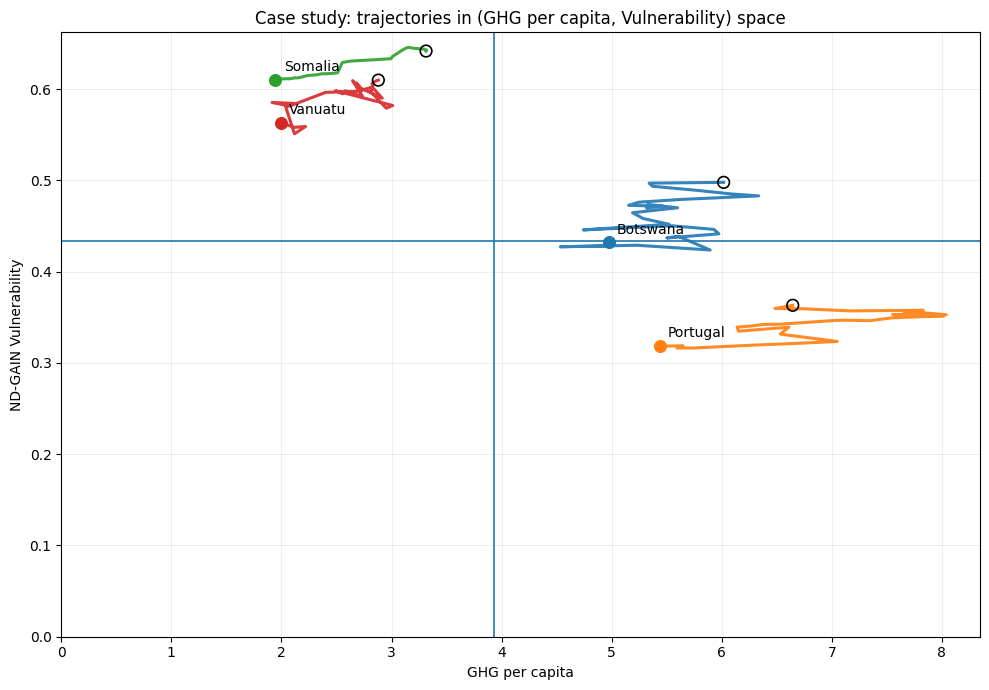

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Quadrantenlinien (globale Mediane)
ax.axvline(ghg_cut, linewidth=1.2)
ax.axhline(vuln_cut, linewidth=1.2)

# Trajektorien + Labels
for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year")
    country = g["Country"].iloc[0]

    # Trajektorie
    ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=2.2,
        alpha=0.9,
    )

    # Start / End
    gs = g[g["is_start"]].iloc[0]
    ge = g[g["is_end"]].iloc[0]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )

    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Namensschild am Endpunkt
    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
        ha="left",
        va="bottom",
    )

# Achsen starten bei 0
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.set_xlabel("GHG per capita")
ax.set_ylabel("ND-GAIN Vulnerability")
ax.set_title("Case study: trajectories in (GHG per capita, Vulnerability) space")

ax.grid(True, linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


## Anpassung: Achsenskalierung + Beschriftungen

1) Die y-Achse wird so skaliert, dass der globale Median (Quadrantenlinie) exakt in der Mitte der Achse liegt.
   Dazu wird die Distanz vom Median zum aktuellen Minimum/Maximum symmetrisch gemacht.

2) Titel und Achsentitel werden inhaltlich angepasst:
   - Titel beschreibt die Fallstudien (sinkende Vulnerability/Unsicherheit + sinkende Emissionen).
   - x-Achse: Treibhausgasemissionen pro Kopf
   - y-Achse: Unsicherheit aufgrund Klimawandels (Label oben an der y-Achse platziert).


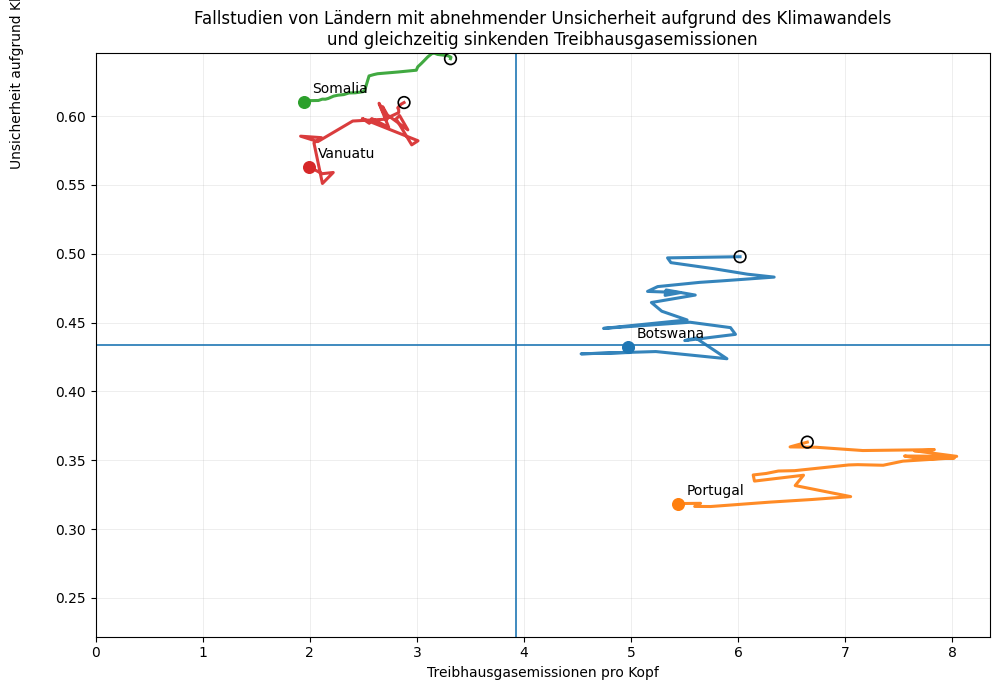

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Quadrantenlinien (globale Mediane)
ax.axvline(ghg_cut, linewidth=1.2)
ax.axhline(vuln_cut, linewidth=1.2)

# Trajektorien + Labels
for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year")
    country = g["Country"].iloc[0]

    ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=2.2,
        alpha=0.9,
    )

    gs = g[g["is_start"]].iloc[0]
    ge = g[g["is_end"]].iloc[0]

    # Start / Ende markieren
    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Namensschild am Endpunkt
    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
        ha="left",
        va="bottom",
    )

# x-Achse startet bei 0
ax.set_xlim(left=0)

# y-Achse: Median exakt in die Mitte (symmetrisch um vuln_cut)
y_min_data = float(case_df["Vulnerability"].min())
y_max_data = float(case_df["Vulnerability"].max())
lower_span = vuln_cut - y_min_data
upper_span = y_max_data - vuln_cut
half_range = max(lower_span, upper_span)

y_lower = max(0.0, vuln_cut - half_range)
y_upper = vuln_cut + half_range
ax.set_ylim(y_lower, y_upper)

# Beschriftungen / Titel
ax.set_xlabel("Treibhausgasemissionen pro Kopf")
ax.set_ylabel("Unsicherheit aufgrund Klimawandels")

ax.set_title(
    "Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels\n"
    "und gleichzeitig sinkenden Treibhausgasemissionen"
)

# Y-Label oben platzieren
ax.yaxis.set_label_coords(-0.08, 1.02)

ax.grid(True, linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


## Iteration: Y-Achse mit Nullstart und zentriertem Median

Die y-Achse (Unsicherheit aufgrund des Klimawandels) startet explizit bei 0.
Um dennoch eine symmetrische Quadranten-Darstellung zu erhalten, wird die
Achse **nach oben erweitert**, sodass der globale Median exakt in der Mitte
der y-Achse liegt.

Damit gilt:
- untere Grenze: 0
- obere Grenze: 2 × Median

So bleibt der Nullpunkt interpretierbar, während die Medianlinie visuell
zentral platziert ist.
m

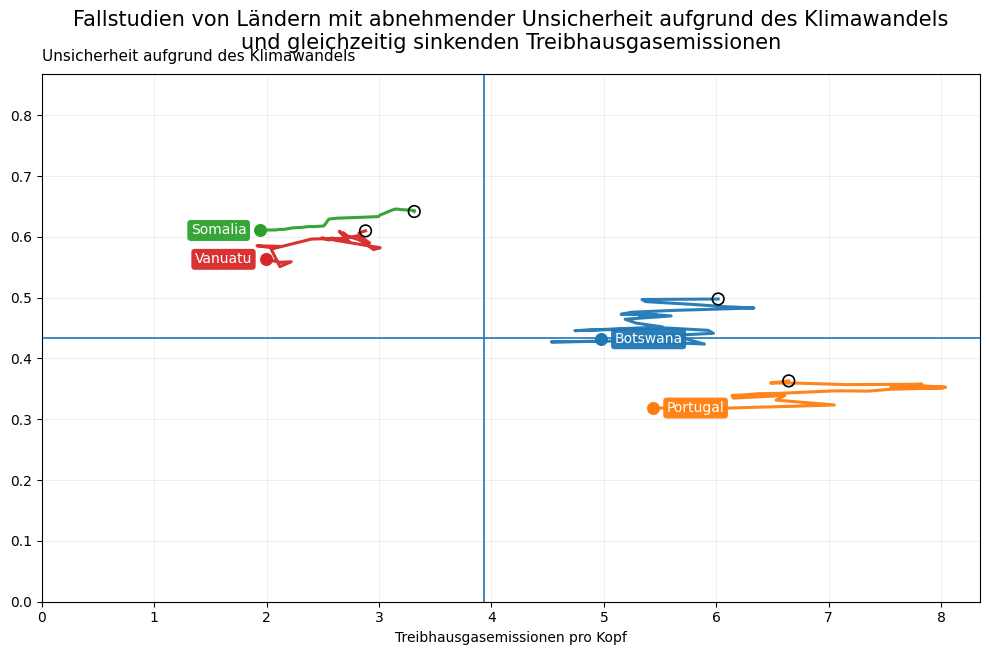

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# --- Quadrantenlinien (globale Mediane) ---
ax.axvline(ghg_cut, linewidth=1.2)
ax.axhline(vuln_cut, linewidth=1.2)

# --- Trajektorien + Start/End + Nametags ---
for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year")
    country = g["Country"].iloc[0]

    # Linie plotten und Farbe abgreifen
    (line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=2.2,
        alpha=0.95,
    )
    col = line.get_color()

    gs = g[g["is_start"]].iloc[0]
    ge = g[g["is_end"]].iloc[0]

    # Start / Ende
    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag am Endpunkt (farbig, nicht ueber der Linie)
    dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
    ha = "left" if dx > 0 else "right"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, 0),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=col,
            edgecolor="none",
            alpha=0.95,
        ),
        zorder=10,
    )

# --- Achsen ---
# x-Achse startet bei 0
ax.set_xlim(left=0)

# y-Achse startet bei 0, Median exakt in der Mitte
y_upper = 2 * vuln_cut
ax.set_ylim(0, y_upper)

# --- Beschriftungen ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

# Y-Label horizontal oben links
ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

ax.set_title(
    "Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels\n"
    "und gleichzeitig sinkenden Treibhausgasemissionen",
    fontsize=15,
    pad=18,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Iteration: Layout-Feinschliff

1) Der Titel wird weiter nach oben verschoben, damit er nicht mit dem horizontalen Y-Achsentitel kollidiert.
2) Die Nametags für Botswana und Portugal werden unterhalb des Endpunkts platziert, damit sie keine Trajektorien schneiden.
3) Die Medianlinien werden dezent beschriftet (unauffällig, nahe an den Linien), um die Quadrantenreferenz klar zu machen,
   ohne die Grafik visuell zu dominieren.


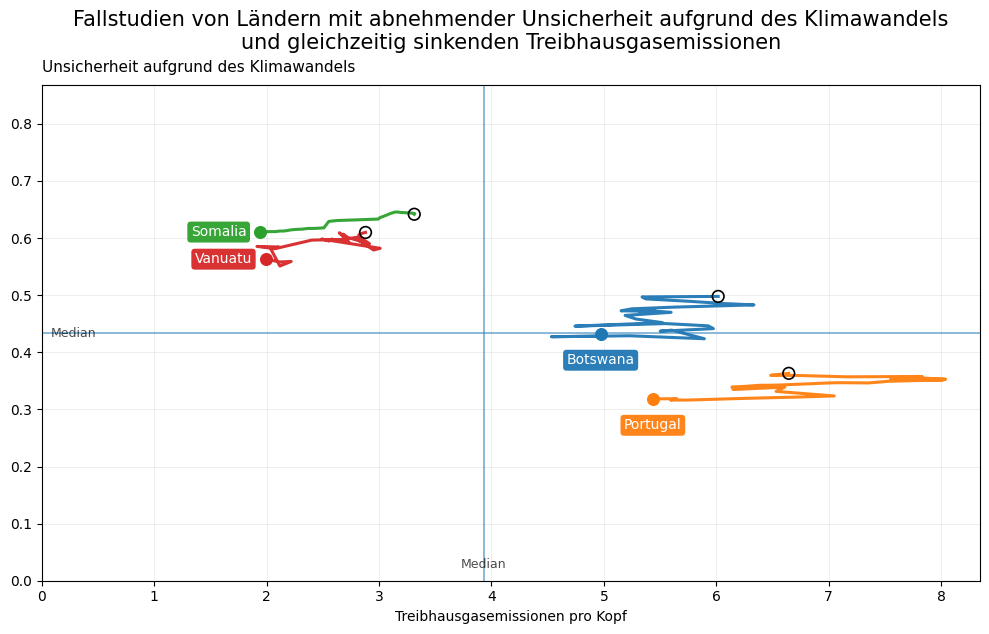

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# --- Quadrantenlinien (globale Mediane) ---
ax.axvline(ghg_cut, linewidth=1.2, alpha=0.6)
ax.axhline(vuln_cut, linewidth=1.2, alpha=0.6)

# --- Trajektorien + Start/End + Nametags ---
for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year")
    country = g["Country"].iloc[0]

    (line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=2.2,
        alpha=0.95,
    )
    col = line.get_color()

    gs = g[g["is_start"]].iloc[0]
    ge = g[g["is_end"]].iloc[0]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag-Placement:
    # Standard: seitlich rechts/links vom Endpunkt
    # Botswana & Portugal: unter Endpunkt (damit kein Trace geschnitten wird)
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=col,
            edgecolor="none",
            alpha=0.95,
        ),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Unauffaellige Median-Beschriftung ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.text(
    ghg_cut,
    y0 + 0.02 * (y1 - y0),
    "Median",
    ha="center",
    va="bottom",
    fontsize=9,
    alpha=0.7,
)

ax.text(
    x0 + 0.01 * (x1 - x0),
    vuln_cut,
    "Median",
    ha="left",
    va="center",
    fontsize=9,
    alpha=0.7,
)

# --- Labels / Titel ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

ax.set_title(
    "Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels\n"
    "und gleichzeitig sinkenden Treibhausgasemissionen",
    fontsize=15,
    pad=26,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# Mehr Platz oben fuer Titel + Y-Header
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## Iteration: Median-Labels, Zeitverlauf, Start/End-Legende

1) Die Median-Beschriftungen werden so versetzt, dass sie die Medianlinien nicht schneiden (Offset + Box).
2) Der Zeitverlauf wird durch einen Opacity-Verlauf sichtbar: frühe Jahre sind transparenter, spätere Jahre opaker.
3) Eine kleine Legende erklärt Start vs. Ende: leerer Punkt = Startjahr, voller Punkt = Endjahr (mit Jahreszahlen).


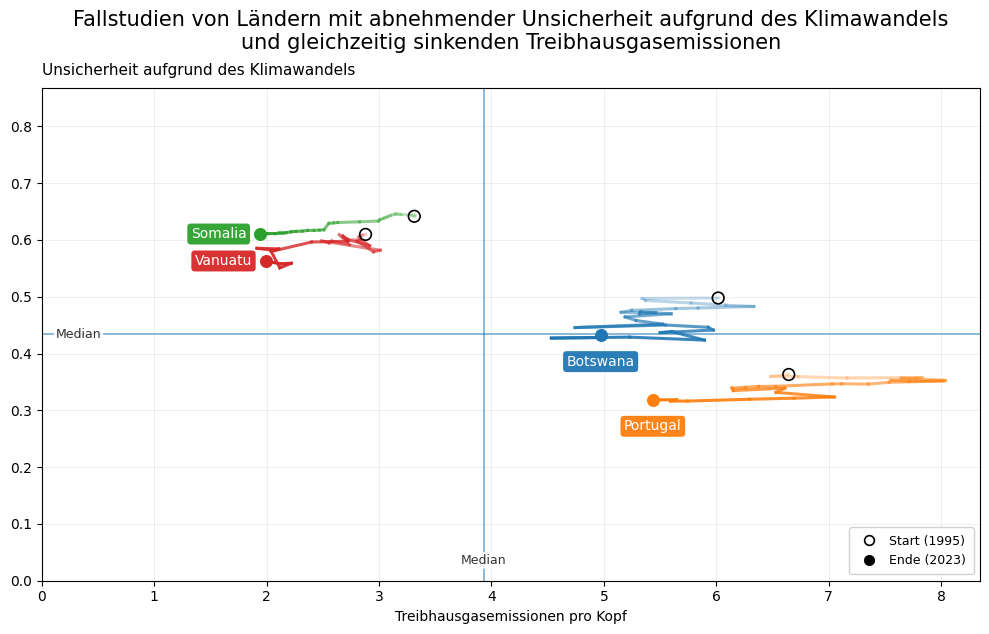

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

# --- Quadrantenlinien (globale Mediane) ---
ax.axvline(ghg_cut, linewidth=1.2, alpha=0.6)
ax.axhline(vuln_cut, linewidth=1.2, alpha=0.6)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    # Start/End-Jahr merken (für Legende)
    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # Basisfarbe aus einem "unsichtbaren" Line2D holen (gleiche Farbvergabe wie vorher)
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    # Opacity-Verlauf: früh transparent -> spät opak
    n = len(g)
    if n <= 1:
        alphas = [1.0]
    else:
        alphas = np.linspace(0.25, 1.0, n - 1)

    # Segmente plotten (jeder Jahres-Schritt ein Segment mit eigener Alpha)
    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    # Start/End Punkte
    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag-Placement (wie vorher)
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=col, edgecolor="none", alpha=0.95),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung: Offset + kleine Box, damit keine Linie "durch den Text" geht ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

# Vertikale Medianlinie (x): Label leicht oberhalb der x-Achse (nicht auf der Linie)
ax.annotate(
    "Median",
    (ghg_cut, y0),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=9,
    alpha=0.8,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# Horizontale Medianlinie (y): Label leicht links vom Plot, aber versetzt (nicht auf der Linie)
ax.annotate(
    "Median",
    (x0, vuln_cut),
    xytext=(10, 0),
    textcoords="offset points",
    ha="left",
    va="center",
    fontsize=9,
    alpha=0.8,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels / Titel ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

ax.set_title(
    "Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels\n"
    "und gleichzeitig sinkenden Treibhausgasemissionen",
    fontsize=15,
    pad=28,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## Iteration: Titel-Prefix + Median-Labels ausserhalb der Linien

1) Der Titel beginnt mit einem fett gesetzten Prefix "Good Cases:" (ohne Sternchen).
2) Das Median-Label der Vulnerability (horizontale Linie) wird unterhalb der Achse platziert, damit es die Linie nicht schneidet.
3) Das Median-Label der GHG (vertikale Linie) wird rechts neben die Linie gesetzt, damit es nicht auf der Linie liegt.
Der restliche Plot (Trajektorien mit Opacity-Verlauf, Nametags, Start/End-Legende) bleibt gleich.
m

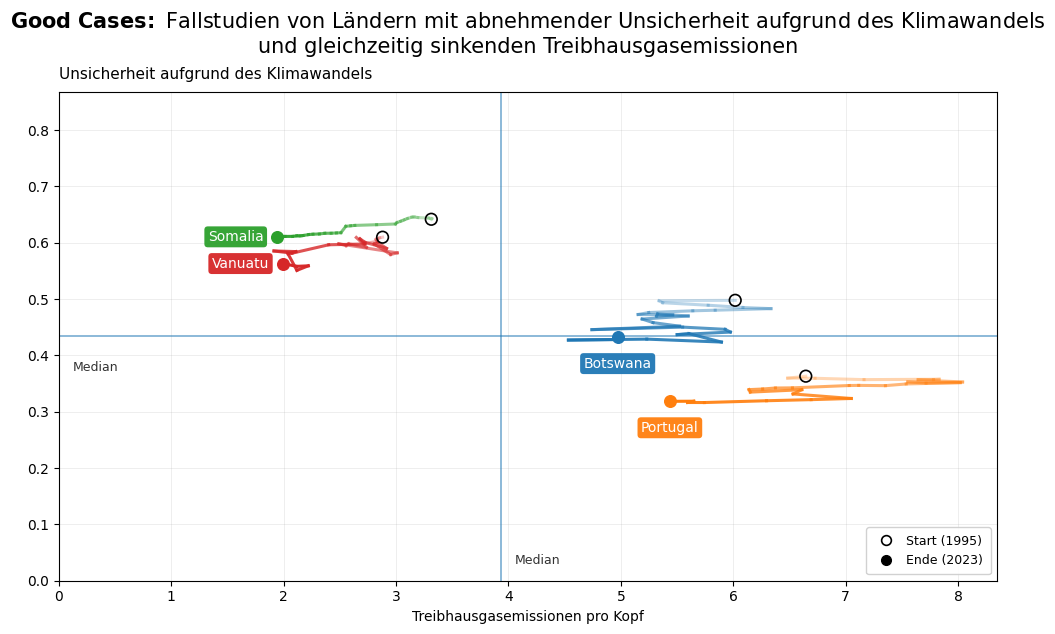

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

# --- Quadrantenlinien (globale Mediane) ---
ax.axvline(ghg_cut, linewidth=1.2, alpha=0.6)
ax.axhline(vuln_cut, linewidth=1.2, alpha=0.6)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # Farbe konsistent aus Matplotlib-Cycle holen
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    # Opacity-Verlauf: früh transparent -> spät opak
    n = len(g)
    if n <= 1:
        alphas = [1.0]
    else:
        alphas = np.linspace(0.25, 1.0, n - 1)

    # Segmente plotten
    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    # Start/End Punkte
    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag-Placement (Botswana/Portugal unter Endpunkt)
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=col,
            edgecolor="none",
            alpha=0.95,
        ),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung: ausserhalb der Linien ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

# Vulnerability-Median (horizontale Linie): Label unterhalb (damit es nicht schneidet)
ax.annotate(
    "Median",
    (x0, vuln_cut),
    xytext=(10, -18),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    alpha=0.8,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# GHG-Median (vertikale Linie): Label rechts davon
ax.annotate(
    "Median",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    alpha=0.8,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

# --- Titel: Good Cases fett, ohne Sternchen im Text ---
ax.set_title(
    r"$\bf{Good\ Cases\!:}$ Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels"
    "\nund gleichzeitig sinkenden Treibhausgasemissionen",
    fontsize=15,
    pad=28,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## Iteration: Medianlabels stylen, Titel umbrechen, SVG Export

1) Die Medianbeschriftungen erhalten die gleiche Farbe/Transparenz wie die Medianlinien
   und werden inhaltlich spezifiziert (Median Unsicherheit / Median Emissionen).
2) Der Titel wird so umgebrochen, dass er optisch zur Plotbreite passt und nicht mit dem Y-Header kollidiert.
3) Die Grafik wird als SVG mit transparentem Hintergrund gespeichert (paper-/slide-tauglich).


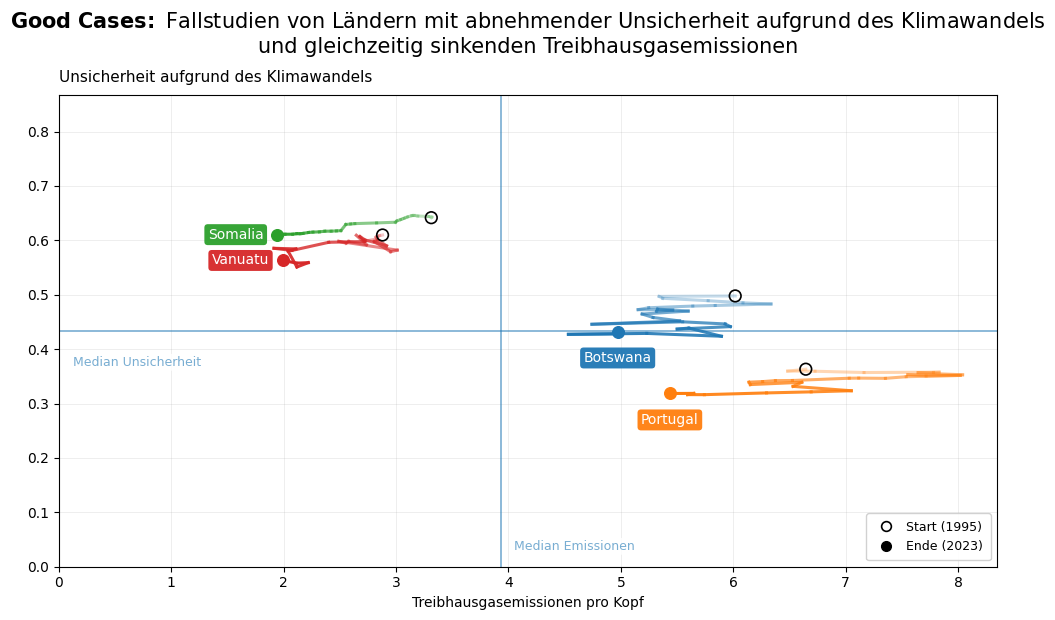

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

# --- Styles fuer Medianlinien und -labels (einheitlich) ---
median_alpha = 0.6
median_lw = 1.2
median_color = "#1f77b4"  # gleiche Farbe wie Matplotlib default blue; passt zu deiner Linie

# Medianlinien
ax.axvline(ghg_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)
ax.axhline(vuln_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # Farbe konsistent aus Matplotlib-Cycle holen
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    n = len(g)
    alphas = [1.0] if n <= 1 else np.linspace(0.25, 1.0, n - 1)

    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag-Placement (Botswana/Portugal unter Endpunkt)
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=col, edgecolor="none", alpha=0.95),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung: gleiche Farbe wie Linie + erklaerend ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

# Median Unsicherheit (horizontale Linie): unterhalb der Linie, links
ax.annotate(
    "Median Unsicherheit",
    (x0, vuln_cut),
    xytext=(10, -18),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# Median Emissionen (vertikale Linie): rechts neben Linie, unten
ax.annotate(
    "Median Emissionen",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

# --- Titel: so umbrechen, dass er zur Plotbreite passt und nicht mit Y-Header kollidiert ---
ax.set_title(
    r"$\bf{Good\ Cases\!:}$ Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels"
    "\nund gleichzeitig sinkenden Treibhausgasemissionen",
    fontsize=15,
    pad=30,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

# Layout: Platz fuer Titel + Y-Header
fig.tight_layout(rect=[0, 0, 1, 0.90])

# --- Export: SVG mit transparentem Hintergrund ---
out_svg = "case_study_good_cases.svg"
fig.savefig(out_svg, format="svg", transparent=True, bbox_inches="tight")

plt.show()


## Iteration: Titelbreite an Plotbox anpassen + Medianlabel naeher an Linie

1) Der Titel wird innerhalb der Plotbox "gewrappt" (automatischer Zeilenumbruch),
   damit seine Breite optisch der Plotbox entspricht statt der gesamten Figurebreite.
2) Das Label "Median Unsicherheit" wird näher an die horizontale Medianlinie gesetzt (kleinerer Offset),
   bleibt aber unterhalb der Linie, damit es sie nicht schneidet.


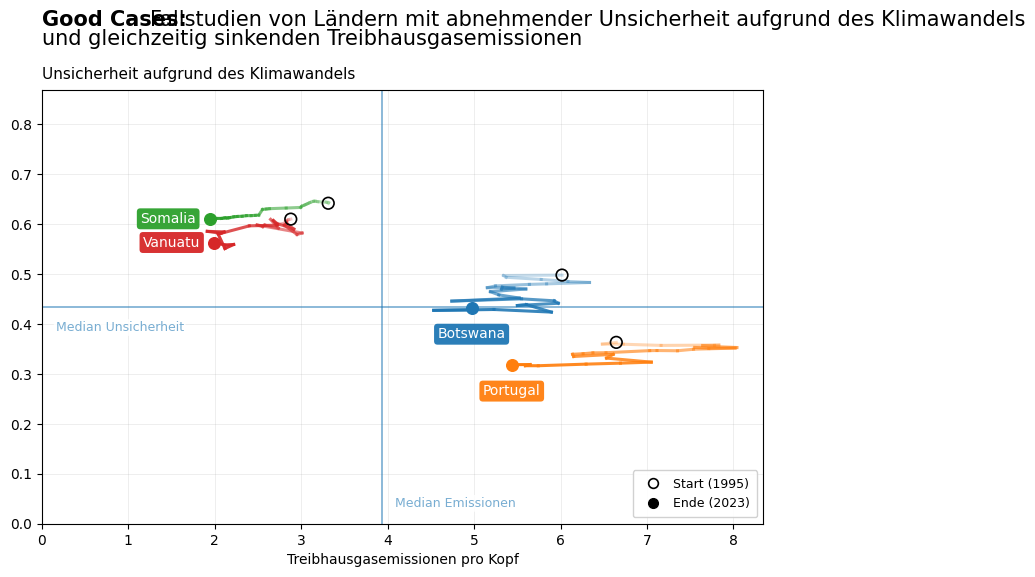

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from textwrap import fill

fig, ax = plt.subplots(figsize=(10, 7))

# --- Styles fuer Medianlinien und -labels (einheitlich) ---
median_alpha = 0.6
median_lw = 1.2
median_color = "#1f77b4"

# Medianlinien
ax.axvline(ghg_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)
ax.axhline(vuln_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # Farbe konsistent aus Matplotlib-Cycle holen
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    n = len(g)
    alphas = [1.0] if n <= 1 else np.linspace(0.25, 1.0, n - 1)

    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=col, edgecolor="none", alpha=0.95),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung: naeher an Linie (Unsicherheit) + gleiches Styling ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.annotate(
    "Median Unsicherheit",
    (x0, vuln_cut),
    xytext=(10, -10),  # naeher an Linie (vorher -18)
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

ax.annotate(
    "Median Emissionen",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

# --- Titel: innerhalb der Plotbox umbrechen (breite ~ Plotbox) ---
title_raw = "Good Cases: Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels und gleichzeitig sinkenden Treibhausgasemissionen"
title_wrapped = fill(title_raw, width=78)  # ggf. 74-84 feinjustieren, je nach Figure-Size

ax.set_title(
    title_wrapped,
    fontsize=15,
    pad=30,
    fontweight="normal",
)

# "Good Cases:" fett innerhalb des Titels (ohne mathtext)
# Workaround: zweiten Textlayer nur fuer den Prefix (an gleicher Position)
# -> stabiler: wir zeichnen den Prefix separat und lassen ihn aus dem Titeltext raus.
ax.set_title("", pad=30)  # Titel leer, wir setzen ihn manuell per ax.text unten

# Manueller Titel: Prefix fett + Rest normal, mit Wrapping
prefix = "Good Cases:"
rest = " Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels und gleichzeitig sinkenden Treibhausgasemissionen"
rest_wrapped = fill(rest.strip(), width=78)

# Erste Zeile: Prefix + Anfang Rest (bis zum ersten Umbruch)
lines = rest_wrapped.split("\n")
first_line = lines[0]
other_lines = "\n".join(lines[1:])

ax.text(
    0.0, 1.14,
    prefix,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=15,
    fontweight="bold",
)

ax.text(
    0.15, 1.14,  # kleiner Einzug nach dem Prefix; ggf. 0.13-0.17 feinjustieren
    first_line,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=15,
)

if other_lines:
    ax.text(
        0.0, 1.095,
        other_lines,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=15,
    )

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

# Layout: mehr Platz oben fuer manuellen Titel + Y-Header
fig.tight_layout(rect=[0, 0, 1, 0.86])

# Export SVG transparent
out_svg = "case_study_good_cases.svg"
fig.savefig(out_svg, format="svg", transparent=True, bbox_inches="tight")

plt.show()


## Iteration: Titel sauber setzen (2 Zeilen, innerhalb der Plotbox)

Der Titel wird nicht mehr ueber ax.set_title gesetzt, sondern als zwei Textzeilen
innerhalb der Axes-Koordinaten platziert:

1) Zeile 1: "Good Cases:" fett (alleinstehend)
2) Zeile 2: Resttitel normal, automatisch umgebrochen und auf die Plotbox-Breite begrenzt
   (links und rechts innerhalb der Axes, nicht ueber die Figurebreite).

So bleibt der Titel optisch exakt so breit wie die Plotbox und kollidiert nicht mit dem Y-Header.


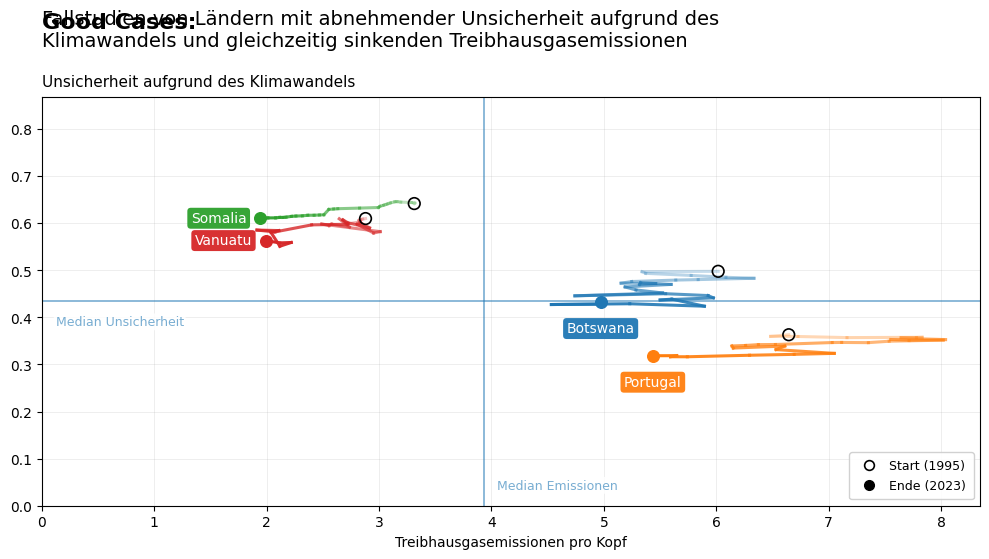

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from textwrap import fill

fig, ax = plt.subplots(figsize=(10, 7))

# --- Styles fuer Medianlinien und -labels (einheitlich) ---
median_alpha = 0.6
median_lw = 1.2
median_color = "#1f77b4"

# Medianlinien
ax.axvline(ghg_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)
ax.axhline(vuln_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    n = len(g)
    alphas = [1.0] if n <= 1 else np.linspace(0.25, 1.0, n - 1)

    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=col, edgecolor="none", alpha=0.95),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.annotate(
    "Median Unsicherheit",
    (x0, vuln_cut),
    xytext=(10, -10),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

ax.annotate(
    "Median Emissionen",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

# --- Titel: 2 Zeilen, innerhalb der Plotbox, keine Ueberbreite ---
# Wir setzen ax.set_title bewusst NICHT.
title_prefix = "Good Cases:"
title_rest = "Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels und gleichzeitig sinkenden Treibhausgasemissionen"

# Wrap so, dass es innerhalb der Plotbox bleibt (Breite in Zeichen: 60-70 ist hier typischerweise gut)
title_rest_wrapped = fill(title_rest, width=68)

# Position: ueber der Axes, aber an Axes gebunden (nicht Figure)
ax.text(
    0.0, 1.16,
    title_prefix,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    0.0, 1.115,
    title_rest_wrapped,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=14,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

# Layout: mehr Platz oben fuer 2-Zeilen-Titel + Y-Header
fig.tight_layout(rect=[0, 0, 1, 0.84])

# Export SVG transparent
out_svg = "case_study_good_cases.svg"
fig.savefig(out_svg, format="svg", transparent=True, bbox_inches="tight")

plt.show()


## Fix: Titel sauber und stabil platzieren

Der Titel wird nicht mehr mit ax.text in Axes-Koordinaten ueber 1.0 gesetzt (das fuehrt mit tight_layout oft zu Ueberlagerungen),
sondern in Figure-Koordinaten exakt ueber der Plotbox (Axes-Bounding-Box).

- Zeile 1: "Good Cases:" fett, alleine
- Zeile 2+: Resttitel normal, automatisch umgebrochen und auf die Plotbox-Breite beschraenkt

So bleibt der Titel links/rechts innerhalb der Plotbox und schneidet nichts.


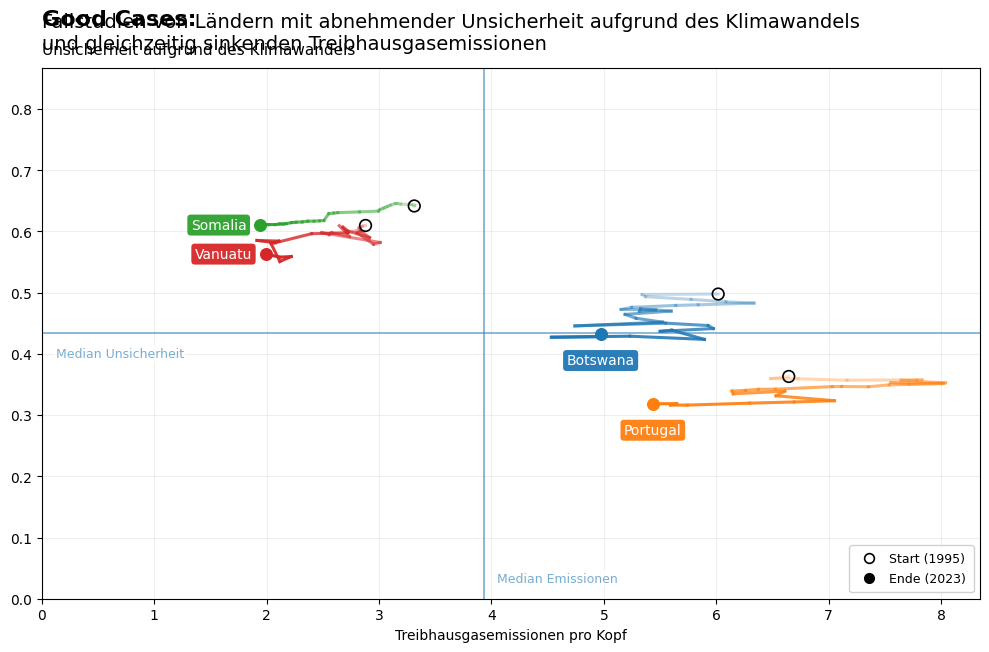

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from textwrap import fill

fig, ax = plt.subplots(figsize=(10, 7))

# --- Styles fuer Medianlinien und -labels (einheitlich) ---
median_alpha = 0.6
median_lw = 1.2
median_color = "#1f77b4"

# Medianlinien
ax.axvline(ghg_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)
ax.axhline(vuln_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # Farbe konsistent aus Matplotlib-Cycle holen
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    n = len(g)
    alphas = [1.0] if n <= 1 else np.linspace(0.25, 1.0, n - 1)

    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametag-Placement (Botswana/Portugal unter Endpunkt)
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=col, edgecolor="none", alpha=0.95),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

# --- Median-Beschriftung (erklaerend, gleiche Farbe wie Medianlinien) ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.annotate(
    "Median Unsicherheit",
    (x0, vuln_cut),
    xytext=(10, -10),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

ax.annotate(
    "Median Emissionen",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Labels ---
ax.set_xlabel("Treibhausgasemissionen pro Kopf")

# Y-Header horizontal
ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Mini-Legende: Start/End mit Jahreszahlen ---
start_year = min(start_years) if start_years else None
end_year = max(end_years) if end_years else None

handles = []
labels = []

if start_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="none", markeredgecolor="black",
                          markeredgewidth=1.2, markersize=7))
    labels.append(f"Start ({start_year})")

if end_year is not None:
    handles.append(Line2D([0], [0], marker="o", linestyle="None",
                          markerfacecolor="black", markeredgecolor="black",
                          markersize=7))
    labels.append(f"Ende ({end_year})")

if handles:
    ax.legend(
        handles, labels,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        fontsize=9,
        borderpad=0.6,
        handletextpad=0.6,
    )

# -------- TITEL-FIX (robust): in Figure-Koordinaten ueber Plotbox --------
# Erst Layout setzen, dann Position der Axes nehmen
fig.tight_layout(rect=[0, 0, 1, 0.90])

bbox = ax.get_position()            # Figure-Koordinaten
x_left = bbox.x0
y_top = bbox.y1

prefix = "Good Cases:"
rest = ("Fallstudien von Ländern mit abnehmender Unsicherheit aufgrund des Klimawandels "
        "und gleichzeitig sinkenden Treibhausgasemissionen")

# Umbruch so, dass es typischerweise in die Plotbox passt (bei figsize (10,7) ist ~78 gut)
rest_wrapped = fill(rest, width=78)

# Zeile 1 (bold)
fig.text(
    x_left, y_top + 0.055,
    prefix,
    ha="left",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

# Zeile 2+ (normal, umgebrochen)
fig.text(
    x_left, y_top + 0.020,
    rest_wrapped,
    ha="left",
    va="bottom",
    fontsize=14,
)

# --- Export SVG transparent ---
out_svg = "case_study_good_cases.svg"
fig.savefig(out_svg, format="svg", transparent=True, bbox_inches="tight")

plt.show()


## Fix: Titel vollständig entfernen

Der komplette Titelcode wird entfernt.
Die Grafik enthält **keinen Titel mehr** – nur Achsen, Medianlinien, Labels und Legende.
So ist der Plot stabil, ruhig und paper-tauglich.


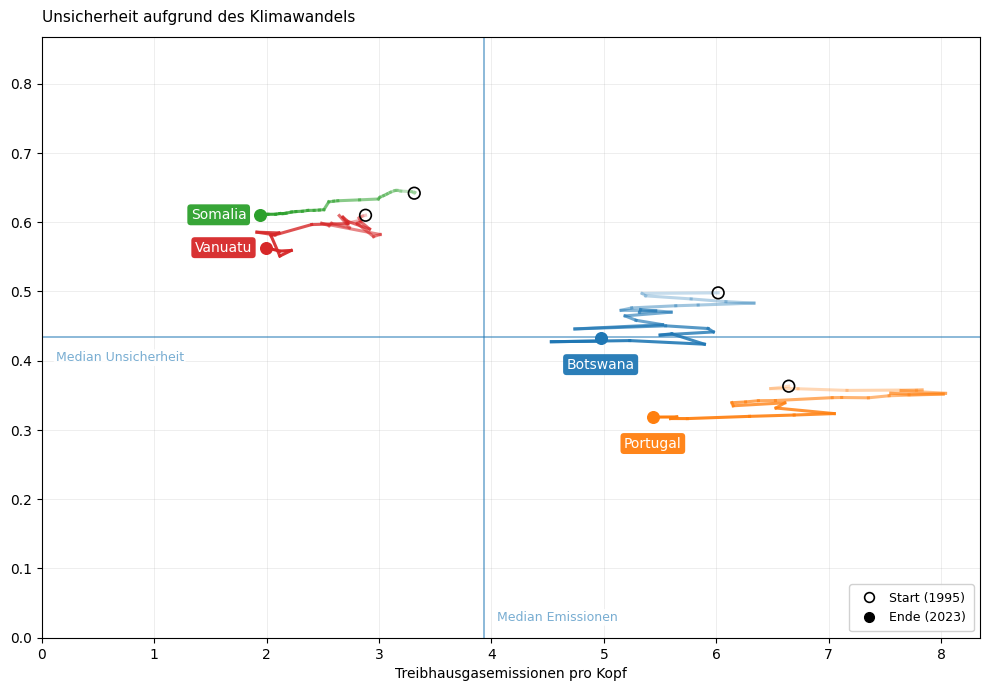

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

# --- Styles fuer Medianlinien ---
median_alpha = 0.6
median_lw = 1.2
median_color = "#1f77b4"

# Medianlinien
ax.axvline(ghg_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)
ax.axhline(vuln_cut, linewidth=median_lw, alpha=median_alpha, color=median_color)

# --- Trajektorien mit Opacity-Verlauf + Start/End + Nametags ---
start_years = []
end_years = []

for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year").reset_index(drop=True)
    country = g["Country"].iloc[0]

    start_years.append(int(g["Year"].iloc[0]))
    end_years.append(int(g["Year"].iloc[-1]))

    # konsistente Farbe
    (base_line,) = ax.plot(
        g["GHG_per_capita"],
        g["Vulnerability"],
        linewidth=0.0,
        alpha=0.0,
    )
    col = base_line.get_color()

    n = len(g)
    alphas = [1.0] if n <= 1 else np.linspace(0.25, 1.0, n - 1)

    for i in range(n - 1):
        ax.plot(
            g.loc[i:i+1, "GHG_per_capita"],
            g.loc[i:i+1, "Vulnerability"],
            linewidth=2.2,
            color=col,
            alpha=float(alphas[i]),
            zorder=2,
        )

    # Start / End Punkte
    gs = g.iloc[0]
    ge = g.iloc[-1]

    ax.scatter(
        gs["GHG_per_capita"],
        gs["Vulnerability"],
        s=70,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        ge["GHG_per_capita"],
        ge["Vulnerability"],
        s=70,
        zorder=6,
    )

    # Nametags
    if country in {"Botswana", "Portugal"}:
        dx, dy = 0, -14
        ha, va = "center", "top"
    else:
        dx = 10 if ge["GHG_per_capita"] >= ghg_cut else -10
        dy = 0
        ha = "left" if dx > 0 else "right"
        va = "center"

    ax.annotate(
        country,
        (ge["GHG_per_capita"], ge["Vulnerability"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color="white",
        ha=ha,
        va=va,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=col,
            edgecolor="none",
            alpha=0.95,
        ),
        zorder=10,
    )

# --- Achsen ---
ax.set_xlim(left=0)
ax.set_ylim(0, 2 * vuln_cut)

ax.set_xlabel("Treibhausgasemissionen pro Kopf")

# Y-Achsentitel horizontal oben links
ax.set_ylabel("")
ax.text(
    0.0, 1.02,
    "Unsicherheit aufgrund des Klimawandels",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
)

# --- Median-Beschriftungen ---
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

ax.annotate(
    "Median Unsicherheit",
    (x0, vuln_cut),
    xytext=(10, -10),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

ax.annotate(
    "Median Emissionen",
    (ghg_cut, y0),
    xytext=(10, 10),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color=median_color,
    alpha=median_alpha,
    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
)

# --- Grid ---
ax.grid(True, linewidth=0.6, alpha=0.25)

# --- Legende: Start / Ende ---
start_year = min(start_years)
end_year = max(end_years)

handles = [
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="none", markeredgecolor="black",
           markeredgewidth=1.2, markersize=7),
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="black", markeredgecolor="black",
           markersize=7),
]

labels = [f"Start ({start_year})", f"Ende ({end_year})"]

ax.legend(
    handles, labels,
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=9,
    borderpad=0.6,
    handletextpad=0.6,
)

# --- Layout + Export ---
fig.tight_layout()

fig.savefig(
    "case_study_good_cases.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

plt.show()
